Dataset loaded successfully!
Number of rows: 9564
Number of columns: 50
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9564 entries, 0 to 9563
Data columns (total 50 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   rowid              9564 non-null   int64  
 1   kepid              9564 non-null   int64  
 2   kepoi_name         9564 non-null   object 
 3   kepler_name        2294 non-null   object 
 4   koi_disposition    9564 non-null   object 
 5   koi_pdisposition   9564 non-null   object 
 6   koi_score          8054 non-null   float64
 7   koi_fpflag_nt      9564 non-null   int64  
 8   koi_fpflag_ss      9564 non-null   int64  
 9   koi_fpflag_co      9564 non-null   int64  
 10  koi_fpflag_ec      9564 non-null   int64  
 11  koi_period         9564 non-null   float64
 12  koi_period_err1    9110 non-null   float64
 13  koi_period_err2    9110 non-null   float64
 14  koi_time0bk        9564 non-null   float64
 15  

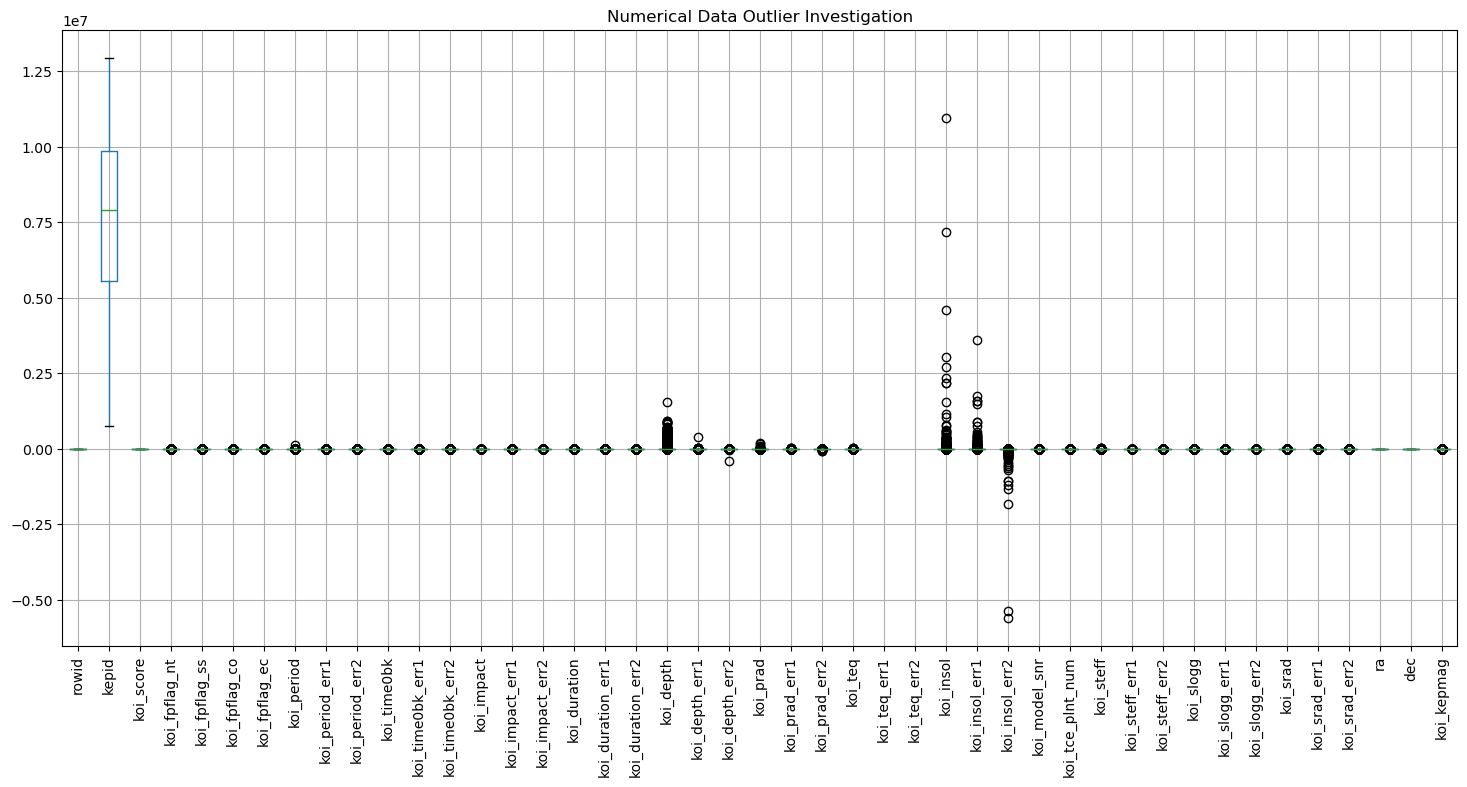


--Datasets--
Original dataset: (9564, 50)
Cleaning dataset: (9564, 50)

--New dataset--
Removed empty columns: 2
New dataset shape: (9564, 48)

--column details--
Original columns: 50
Cleaned columns: 48

--Remaining complete empty col--
Remaining completely empty columns:
[]


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("cumulative.csv",encoding='utf-8',nrows=9564)
print("Dataset loaded successfully!")
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

df.head()
df.info()
df.describe()
df.shape

print(df.head())
print(df.info())
print(df.describe())
print(df.shape)

print("Column names:\n")
for column in df.columns:
    print(column)



print("--------TO FIND EMPTY COLUMNS--------")
empty_columns = []
for column in df.columns:
    if df[column].isnull().all():
        empty_columns.append(column)
print("Completely empty columns:")
print(empty_columns)

print("Number of completely empty columns:", len(empty_columns))



print("-----MISSING VALUES-----")
missing_values = df.isnull().sum()
print(missing_values)


print("------MISSING VALUES PERCENTAGE-------")
missing_percentage = (df.isnull().sum() / len(df)) * 100
print(missing_percentage.round(2))



print("------MISSING REPORT------")
missing_report = pd.DataFrame()
missing_report["Column"] = df.columns
missing_report["Missing Values"] = df.isnull().sum().values
missing_report["Missing Percentage"] = (
    df.isnull().sum().values / len(df) * 100
).round(2)

missing_report



missing_report = missing_report.sort_values(
    "Missing Percentage",
    ascending=False
)
missing_report



print("-----DUPLICATE ROWS------")
duplicate_rows = df.duplicated().sum()
print("Number of duplicate rows:", duplicate_rows)



if duplicate_rows > 0:
    df[df.duplicated()]
else:
    print("No duplicate rows found.")



duplicate_kepoi = df["kepoi_name"].duplicated().sum()
print("Duplicate KOI names:", duplicate_kepoi)


df[df["kepoi_name"].duplicated(keep=False)][
    ["kepoi_name", "koi_disposition"]
].head(20)


print(df["koi_disposition"].value_counts(dropna=False))





print("-----Numerical columns-----")
num_columns = df.select_dtypes(
    include=np.number
).columns
print("Number of numerical columns:", len(num_columns))
print("\nNumerical columns:")
for column in num_columns:
    print(column)



print("-------Catergorical columns-------")
cate_columns = df.select_dtypes(
    include="object"
).columns
print("Number of categorical columns:", len(cate_columns))
print("\nCategorical columns:")
for column in cate_columns:
    print(column)




infi_values = np.isinf(df[num_columns]).sum()
print("Columns with infinite values:")
print(infi_values[infi_values > 0])
print()


neg_values = (df[num_columns] < 0).sum()
print("Columns with negative values:")
print(neg_values[neg_values > 0])
print()




print("--Plotting--")
df[num_columns].boxplot(
    figsize=(18, 8),
    rot=90
)
plt.title("Numerical Data Outlier Investigation")
plt.show()
print()




print("--Datasets--")
df_clean = df.copy()
print("Original dataset:", df.shape)
print("Cleaning dataset:", df_clean.shape)
print()





print("--New dataset--")
df_clean = df_clean.drop(columns=empty_columns)
print("Removed empty columns:", len(empty_columns))
print("New dataset shape:", df_clean.shape)
print()



print("--column details--")
print("Original columns:", len(df.columns))
print("Cleaned columns:", len(df_clean.columns))
print()



print("--Remaining complete empty col--")
print("Remaining completely empty columns:")
print(
    df_clean.columns[
        df_clean.isnull().all()
    ].tolist()
)